# Exploration of R3D data computed with full polarisation matrices in kappa

## Extra codes

### Create gas-kappa-file with empty scatmat-matrix

In [ ]:
# Write empty kappascatmat-file for usage for gas
# or other medium with no scattering.

import analyze_polarization_functions as apf
apf.write_r3d_emptypolarization()


### Remove spikes from images

In [ ]:
# TODO
# fix this code
# if I even need it?

# Remove spikes from Images
import analyze_r3d_functions as a3d
import os

models = [
    '../r3dresults_polarized/st28gm06n052',
    '../r3dresults_polarized/st28gm06n074',
    '../r3dresults_polarized/st28gm06n075',
]
# Loop over models
for model in models:
    print(
        f'Doing {model}'
    )
    # Extract all included snapshot numbers
    phases = [int(filename) for filename in os.listdir(f'{model}_1/') if os.path.isdir(f'{model}_1/{filename}')]
    phases.sort()
    for phase in phases:    
        print(
            f'  snapshot {phase:03d}'
        )
        # Extract all included images
        imagefiles = []
        for filename in os.listdir(f'{model}_1/{phase}/'):
            if filename.split('_')[0] == 'image':
                imagename = filename
                # Remove spikes on images in folders
                image1d = a3d.remove_imagespikes(
                    folders = [
                        f'{model}_1/{phase:03d}/',
                        f'{model}_2/{phase:03d}/',
                        f'{model}_3/{phase:03d}/',
                    ],
                    imagefilename = imagename,
                )
                if os.path.exists(f'{model}_nospikes/{phase:03d}') == False:
                    os.system(f'mkdir {model}_nospikes/{phase:03d}')
                os.system(f'mv ../{imagename} {model}_nospikes/{phase:03d}/')



os.system('spd-say moo')



Doing ../r3dresults_vltcompare/st28gm06n052
  snapshot 166
  snapshot 167
Doing ../r3dresults_vltcompare/st28gm06n074
  snapshot 110
  snapshot 111
Doing ../r3dresults_vltcompare/st28gm06n075
  snapshot 208
  snapshot 209


0

In [1]:
# Interpolate images for missing snapshots
# Interpolates all polarizations as well

# Define stuff
modelname = 'st28gm06n075'
phases = [
    144
]
imagewaves = [
    '0.65','0.82'
]
angles = [
    'i000_phi000',
    'i090_phi000',
    'i090_phi090',
    'i090_phi270',
    'i180_phi000',
    'i270_phi000',
]
# Loop through each phase and interpolate images and SEDs
for phase in phases:
    prev_phase = phase-1
    next_phase = phase+1
    # Loop through angles
    for angle in angles:
        # Fix images
        #
        # Load images and polarizations
        for imagewave in imagewaves:
            # Reset lists
            imageheader = []
            #
            prev_i = []
            prev_q = []
            prev_u = []
            prev_v = []
            #
            next_i = []
            next_q = []
            next_u = []
            next_v = []
            #
            with open(f'../r3dresults_polarized/{modelname}_images/{prev_phase:03d}/image_{angle}_{imagewave}um.out', 'r') as fprev_image:
                for nline,line in enumerate(fprev_image.readlines()):
                    # First save header
                    if nline < 6:
                        imageheader.append(line)
                    if nline >= 6:
                    # Then prev flux densities
                        imagedata = line.split()
                        #
                        if len(imagedata) == 4:
                            prev_i.append(float(imagedata[0]))
                            prev_q.append(float(imagedata[1]))
                            prev_u.append(float(imagedata[2]))
                            prev_v.append(float(imagedata[3]))
            #
            # And next image flux densities
            with open(f'../r3dresults_polarized/{modelname}_images/{next_phase:03d}/image_{angle}_{imagewave}um.out', 'r') as fnext_image:
                for nline,line in enumerate(fnext_image.readlines()):
                    if nline >= 6:
                        imagedata = line.split()
                        #
                        if len(imagedata) == 4:
                            next_i.append(float(imagedata[0]))
                            next_q.append(float(imagedata[1]))
                            next_u.append(float(imagedata[2]))
                            next_v.append(float(imagedata[3]))
            #
            # And save number of pixels
            Npixels = len(next_i)
            #
            # Write new image-files
            with open(f'../r3dresults_polarized/{modelname}_images/{phase:03d}/image_{angle}_{imagewave}um.out', 'w') as fimage:
                #
                # Write header
                for line in imageheader:
                    fimage.write(f'{line}')
                #
                # Write image fluxes and polarizations
                for npixel in range(Npixels):
                    fimage.write(
                        f' {0.5*(prev_i[npixel]+next_i[npixel])}  {0.5*(prev_q[npixel]+next_q[npixel])}  {0.5*(prev_u[npixel]+next_u[npixel])}  {0.5*(prev_v[npixel]+next_v[npixel])}\n'
                    )


## Test code for plotting each polarization component

See Radmc3d-manual for info on polarisation. 

> radmc3d image stokes

Gives image.out-files with 4 columns of pixel data, ie 4 images in each file in the following order:

- I : Total intensity. the incident light
- Q : describes linear polarisation (horizontal or vertical, depending on the sign).
- U : describes polarisation at a 2nd set of orthogonal axes (+/-45 degrees)
- V : describes elliptical polarisation (right-handed if > 0, left-handed < 0)

R3d uses IAU 1974 definition as described in Hamaker & Bregman (1996) A&AS 117, pp.161. (see manual sect 6.9.1 Definitions ...).

All polarised light combines into I via

> I^2 = Q^2 + U^2 + V^2

Only linear polarised light is defined as the complex statement

> L = Q + iU

so that the absolute is (ie the INTENSITY of the LINEAR polarised light)

> |L| = sqrt(Q^2 + U^2)

and the INTENSITY of the CIRCULAR polarised light is simply

> |V| = sqrt(V^2)


All total fluxes - i:
                     6.985e+06 Jy
                     5.689e+06 Jy
                     2.496e+06 Jy
                     4.964e+06 Jy
                     7.089e+06 Jy
                     7.245e+06 Jy
All total fluxes - l:
                     6.513e-85 Jy
                     0.000e+00 Jy
                     0.000e+00 Jy
                     0.000e+00 Jy
                     2.132e-85 Jy
                     0.000e+00 Jy
All total fluxes - v:
                     0.000e+00 Jy
                     0.000e+00 Jy
                     0.000e+00 Jy
                     0.000e+00 Jy
                     0.000e+00 Jy
                     0.000e+00 Jy


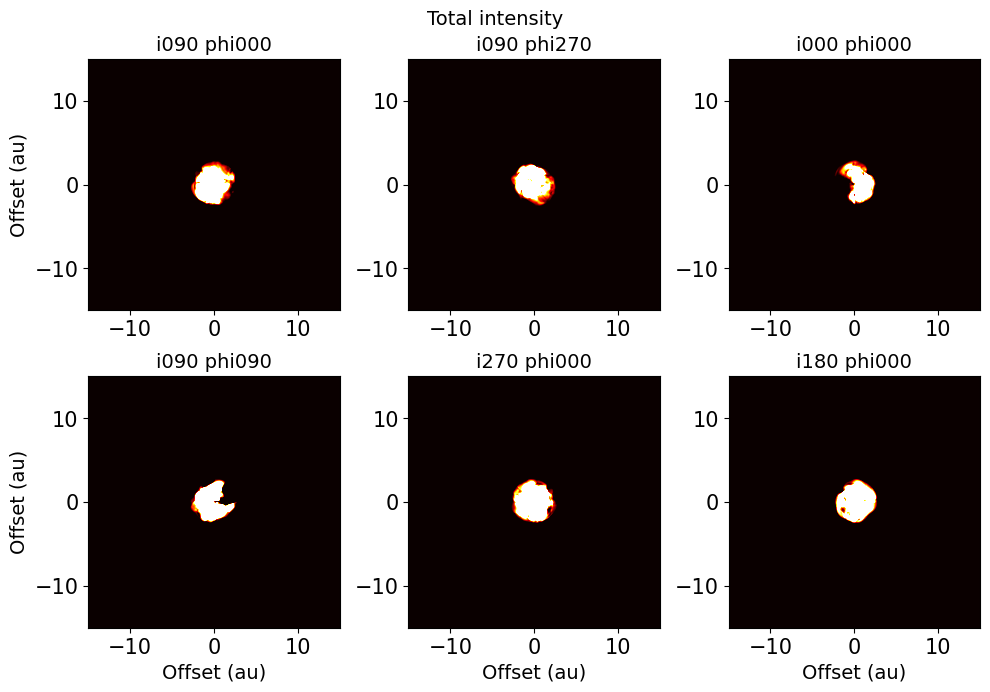

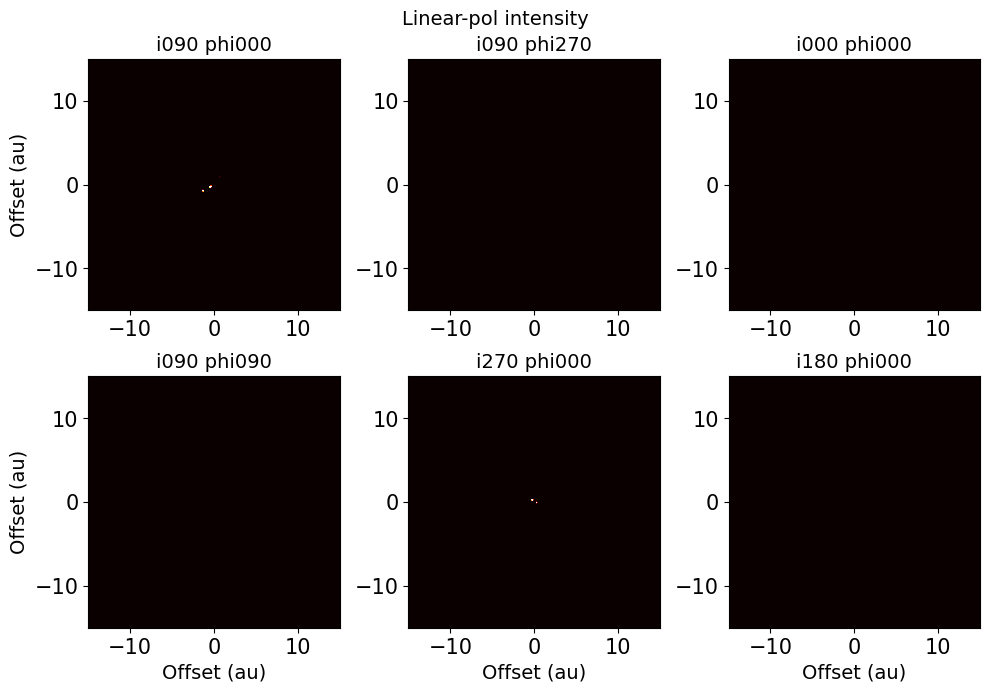

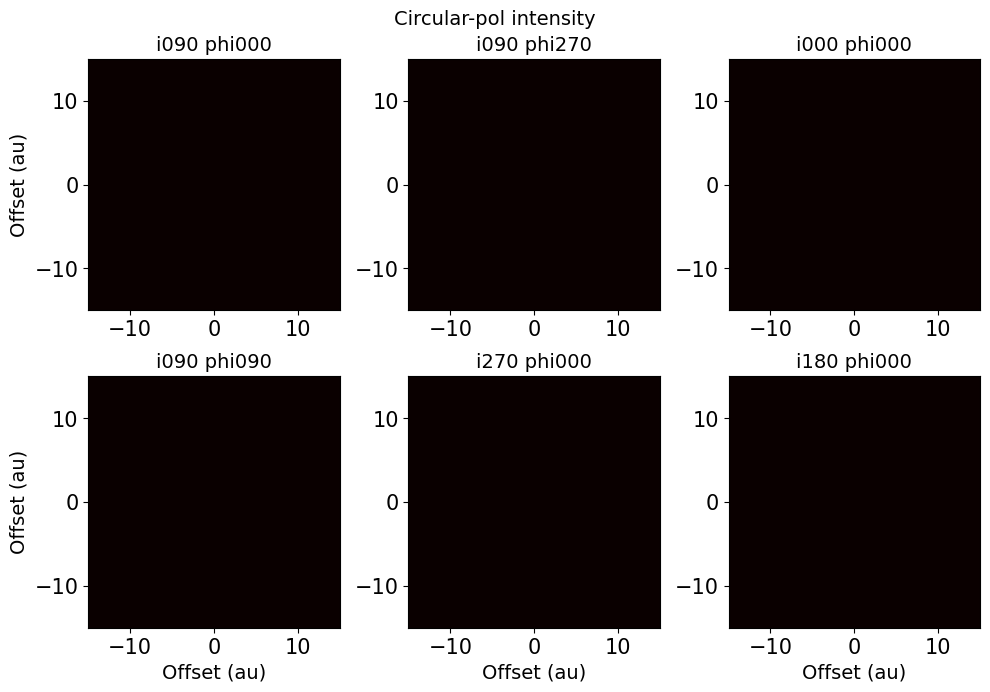

In [5]:
# Plot all images of one polarization and at one snapshot
# and one wavelenght only
#
import analyze_polarization_functions as apf
for polarization in ['i','l','v']:
    fig,ax,fluxtotal = apf.plot_intensity_onepolarization(
        imagepath='../r3dresults_polarized/st28gm06n075_images/200/',
        imagewave=0.65,
        polarization=polarization,
        vmaxcorr=1e-2
    )
    print(f'All total fluxes - {polarization}:')
    for flux in  fluxtotal:
        print(f'                     {flux:.3e} Jy')
    fig.set_figheight(7)
    fig.set_figwidth(10)
    fig.tight_layout()
    fig.subplots_adjust(top=0.92)
    #fig.show()


/tmp/ipykernel_43998/289907507.py:12: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


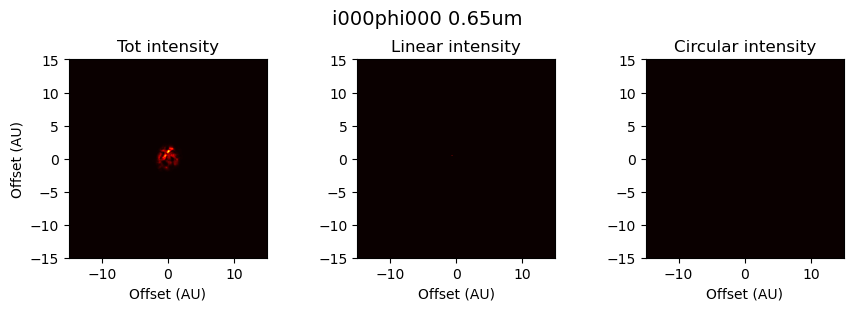

In [2]:
# Plot all polarizations of one angle
# one snapshot, one wavelength
# 
import analyze_polarization_functions as apf
fig,ax = apf.plot_intensity_allpolarizations(
    imagepath='../r3dresults_polarized/st28gm06n075_images/100/',
    imagefile='image_i000_phi000_0.65um.out',
    distance=1,
    vmaxcorr=1
)
fig.tight_layout()
fig.show()

qplus_max : 1.922e+00
qneg_max : -6.768e-85
uplus_max : 1.368e+00
uneg_max : -7.472e-85
vplus_max : 0.000e+00
vneg_max : 0.000e+00


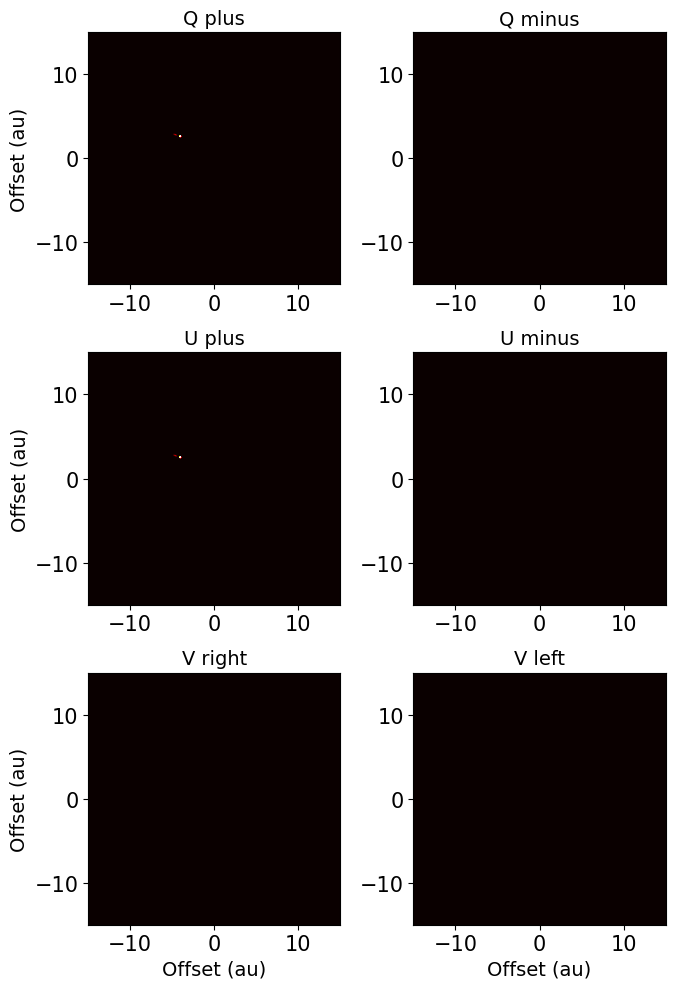

In [6]:
# Plot only strength of polarizations
import analyze_polarization_functions as apf

dict_polarizationmax,fig,ax = apf.plot_allpolarizationdirections(
    imagepath='../r3dresults_polarized/st28gm06n075_images/208/',
    imagefile='image_i000_phi000_0.65um.out',
    distance=1,
    vmaxcorr=1e-1,
)
fig.tight_layout()
for polmax in dict_polarizationmax:
    print(f'{polmax} : {dict_polarizationmax[polmax]:.3e}')


## Extract various useful values from polarized data


In [ ]:
# Extract all integrated polarization intensities
# and write to file
# Also saved in separate script: scriptpy_extractpolarizationintensity.py
import numpy as np
import os

models = [
    #'st28gm06n052',
    #'st28gm06n074',
    'st28gm06n075',
]
wavelengths = [
    '0.65',
    #'0.82',
]
distance = 1
angles = [
    'i000_phi000',
    'i090_phi000',
    'i090_phi090',
    'i090_phi270',
    'i180_phi000',
    'i270_phi000',
]
for wavelength in wavelengths:
    for model in models:

        modelpath = f'../r3dresults_polarized/{model}_images'
        modelname = model

        # Automatically add / to end of path if it's missing
        if modelpath[-1] != '/':
            modelpath += '/'

        # Extract all snapshot numbers for this model
        #snapshots = [int(filename) for filename in os.listdir(modelpath) if os.path.isdir(modelpath+filename)]
        #snapshots.sort()
        snapshots = [150,151]
        Nsnapshots = len(snapshots)

        # Open file to write all coords
        with open(f'{modelpath}polarizationintensity_{wavelength}um.dat','w') as fpol:
            print(
                f'  Writing polarization file\n    {modelpath}polarizationintensity_{wavelength}um.dat'
            )
            # Write header
            fpol.writelines(f'# Polarization intensity at lambda = {wavelength} um for {modelname}\n')
            fpol.writelines(f'Nsnapshots={Nsnapshots}\n')
            fpol.writelines(f'# Angles : \n')
            for angle in angles:
                fpol.writelines(f'    {angle}')
            fpol.writelines('\n# Snapshot      Q U V L for each angle in Jy at 1pc - 2 spaces between intensity and 4 spaces between angles.')
            #
            # Loop over time
            for snapshot in snapshots:
                # Print some output
                if snapshot == 100 or snapshot == 200 or snapshot == 300 or snapshot == 400:
                    print(f'  At snapshot {snapshot}')
                #
                # Print snapshot number to dat file
                fpol.writelines(f'\n{snapshot:03d}    ')
                #
                # Define image folder path
                imagepath = f'{modelpath}{snapshot}/'
                #
                # Loop over angles
                for angle in angles:
                    # Define image file name
                    image = f'image_{angle}_{wavelength}um.out'
                    # Define lists for polarization intensities
                    q_intensity = []
                    u_intensity = []
                    v_intensity = []
                    l_intensity = []
                    # Read image
                    with open(f'{imagepath}{image}', 'r') as fimage:
                        # Loop through image
                        for nl,line in enumerate(fimage.readlines()):
                            # Check if polarized image or not
                            if nl == 0:
                                imagesetting = int(
                                    line.strip()
                                )
                            # Then check polarisation setting
                            if imagesetting == 3:
                                # 3 means full polarisation, continue with extracting data
                                #
                                # row 6 onward: pixel-values, four columns
                                # image.out's pixels has unit
                                # erg s-1 cm-2 Hz-1 ster-1
                                if nl > 5:
                                    if len(line.split()) > 1:
                                        # Loop over polarisation numbers
                                        # Split line and extract each column, strip from \n and make floats
                                        # and change unit to Jy at chosen distance
                                        q_pixeldata = float(line.split()[1].strip()) * 1.e23 * 2.35044305391e-11 / distance**2
                                        u_pixeldata = float(line.split()[2].strip()) * 1.e23 * 2.35044305391e-11 / distance**2
                                        v_pixeldata = float(line.split()[3].strip()) * 1.e23 * 2.35044305391e-11 / distance**2
                                        #
                                        # Save intensities in lists
                                        #
                                        q_intensity.append(
                                            np.sqrt(q_pixeldata*q_pixeldata)
                                        )
                                        u_intensity.append(
                                            np.sqrt(u_pixeldata*u_pixeldata)
                                        )
                                        v_intensity.append(
                                            np.sqrt(v_pixeldata*v_pixeldata)
                                        )
                                        l_intensity.append(
                                            np.sqrt(q_pixeldata*q_pixeldata + u_pixeldata*u_pixeldata)
                                        )
                            else:
                                raise ValueError(
                                    'Not polarized image!'
                                )
                    # Extract total polarized intensity
                    q_total = np.sum(q_intensity)
                    u_total = np.sum(u_intensity)
                    v_total = np.sum(v_intensity)
                    l_total = np.sum(l_intensity)
                    #
                    # Print polarization intensities to file
                    fpol.writelines(
                        f'{q_total:.3e}  {u_total:.3e}  {v_total:.3e}  {l_total:.3e}    '
                    )

        # 8 snapshots: 1min
        # 7.125sek per snapshot
        # 400 tar 50min
        # 450 tar 55min
        # så 3h för 3 modeller 1 våglängd
        # 6h för allt



  Writing polarization file
    ../r3dresults_polarized/st28gm06n075_images/polarizationintensity_0.65um.dat


In [22]:
import numpy as np
import analyze_polarization_functions as apf
snapshots, q_intensity, u_intensity, v_intensity, l_intensity = apf.load_polarizationintensities(
    file_path='../r3dresults_polarized/st28gm06n052_images/polarizationintensity_0.65um.dat',
    angles=[
        #'i000_phi000',
        #'i090_phi000',
        'i090_phi090',
        #'i090_phi270',
        #'i180_phi000',
        #'i270_phi000',
    ],
)
#print(snapshots)
#print(q_intensity)
#print(u_intensity)
#print(v_intensity)
print(l_intensity)

[[0.000e+00]
 [0.000e+00]
 [0.000e+00]
 [2.964e-83]
 [2.290e-82]
 [1.030e-83]
 [6.755e-85]
 [4.725e-84]
 [1.221e-82]
 [6.535e-85]
 [1.139e-78]
 [1.389e-84]
 [3.432e-81]
 [5.312e-81]
 [3.104e-83]
 [3.085e-79]
 [3.439e-83]
 [5.704e-84]
 [2.234e-83]
 [2.424e-82]
 [0.000e+00]
 [4.489e-84]
 [0.000e+00]
 [0.000e+00]
 [1.560e-83]
 [4.298e-83]
 [5.472e-81]
 [5.051e-82]
 [2.437e-85]
 [1.689e-81]
 [7.869e-82]
 [2.757e-83]
 [1.323e-79]
 [1.938e-84]
 [1.249e-83]
 [2.508e-83]
 [1.011e-81]
 [3.060e-84]
 [2.807e-84]
 [1.079e-84]
 [4.830e-84]
 [4.548e-79]
 [1.262e-83]
 [3.909e-83]
 [1.488e-79]
 [6.933e-81]
 [1.912e-83]
 [0.000e+00]
 [4.224e-84]
 [0.000e+00]
 [3.223e-81]
 [8.617e-85]
 [7.431e-85]
 [9.562e-84]
 [4.034e-84]
 [2.112e-83]
 [7.754e-85]
 [3.646e-84]
 [3.933e-84]
 [9.808e-83]
 [1.079e-80]
 [1.724e-82]
 [9.832e-84]
 [4.538e-82]
 [0.000e+00]
 [2.966e-85]
 [1.696e-84]
 [3.345e-84]
 [6.491e-82]
 [3.930e-83]
 [5.873e-85]
 [0.000e+00]
 [2.208e-82]
 [0.000e+00]
 [6.137e-84]
 [2.052e-82]
 [7.263e-80]